# Многокритериальная оптимизация

Эволюционный алгоритм одновременно минимизирует смертность и пик инфекции.
В допустимое множество входят решения с пиком не выше 30%; недопустимые
решения получают штраф. Отбор использует Парето-ранг и crowding distance.

## Подключение проекта

In [1]:
using DrWatson
@quickactivate "AgentSIRLab"
using DataFrames, Random, Statistics
include(srcdir("experiment_tools.jl"))

summarize_groups (generic function with 1 method)

## Кодирование решения и целевая функция

In [2]:
const NOPT = 1500
decode(x) = (detection_time=clamp(round(Int, x[1]), 2, 10),
             beta_detected=clamp(x[2], 0.01, 0.18),
             migration=clamp(x[3], 0.0, 0.25),
             quarantine_threshold=clamp(x[4], 0.03, 0.18))

function evaluate(x)
    p = decode(x)
    metrics = NamedTuple[]
    for seed in (251, 252)
        _, rows = run_sir(Ns=[500, 500, 500], β_und=fill(0.5, 3),
            β_det=fill(p.beta_detected, 3), infection_period=14,
            detection_time=p.detection_time, death_rate=0.02,
            reinfection_probability=0.1, Is=[4, 0, 0],
            migration_rates=migration_matrix(3, p.migration), seed=seed,
            quarantine_enabled=true, quarantine_threshold=p.quarantine_threshold,
            n_steps=120)
        push!(metrics, epidemic_metrics(DataFrame(rows), NOPT))
    end
    peak = mean(m.peak_fraction for m in metrics)
    deaths = mean(m.deaths for m in metrics) / NOPT
    violation = max(0.0, peak - 0.30)
    return (death_fraction=deaths + 10violation, peak_fraction=peak + 10violation,
            raw_death_fraction=deaths, raw_peak_fraction=peak)
end

dominates(a, b) = all(a .<= b) && any(a .< b)
function pareto_ranks(values)
    remaining, ranks, rank = collect(eachindex(values)), zeros(Int, length(values)), 1
    while !isempty(remaining)
        front = [i for i in remaining if !any(j -> j != i && dominates(values[j], values[i]), remaining)]
        ranks[front] .= rank
        remaining = setdiff(remaining, front)
        rank += 1
    end
    return ranks
end

function crowding(values, ranks)
    distance = zeros(length(values))
    for rank in unique(ranks)
        front = findall(==(rank), ranks)
        length(front) <= 2 && (distance[front] .= Inf; continue)
        for objective in 1:2
            ordered = sort(front; by=i -> values[i][objective])
            distance[ordered[[1, end]]] .= Inf
            span = values[ordered[end]][objective] - values[ordered[1]][objective]
            span == 0 && continue
            for k in 2:length(ordered)-1
                distance[ordered[k]] += (values[ordered[k+1]][objective] - values[ordered[k-1]][objective]) / span
            end
        end
    end
    return distance
end

crowding (generic function with 1 method)

## Эволюционный поиск NSGA-II

In [3]:
rng = Xoshiro(404)
random_candidate() = [rand(rng, 2:10), rand(rng) * 0.17 + 0.01,
                      rand(rng) * 0.25, rand(rng) * 0.15 + 0.03]
population = [random_candidate() for _ in 1:18]
history_rows = NamedTuple[]
for generation in 1:7
    global population
    scores = [evaluate(x) for x in population]
    objectives = [(s.death_fraction, s.peak_fraction) for s in scores]
    ranks = pareto_ranks(objectives)
    distance = crowding(objectives, ranks)
    for (index, (x, score)) in enumerate(zip(population, scores))
        p = decode(x)
        push!(history_rows, merge((generation=generation, candidate=index, rank=ranks[index],
            crowding=distance[index]), p, score))
    end
    order = sortperm(eachindex(population); by=i -> (ranks[i], -distance[i]))
    parents = population[order[1:9]]
    children = Vector{Float64}[]
    while length(children) < 9
        a, b = rand(rng, parents, 2)
        λ = rand(rng)
        child = λ .* a .+ (1 - λ) .* b
        child .+= [randn(rng) * 0.7, randn(rng) * 0.015, randn(rng) * 0.025, randn(rng) * 0.015]
        push!(children, collect(Float64, child))
    end
    population = vcat(copy.(parents), children)
end
history = save_frame(DataFrame(history_rows), "sir-optimize-parameters", "optimization-history.csv")
final = filter(:generation => ==(maximum(history.generation)), history)
pareto = filter(:rank => ==(1), final)
save_frame(pareto, "sir-optimize-parameters", "pareto-front.csv")
feasible = filter(:raw_peak_fraction => <=(0.30), pareto)
selection_pool = isempty(feasible) ? pareto : feasible
best = selection_pool[argmin(selection_pool.raw_death_fraction), :]
save_frame(DataFrame([NamedTuple(best)]), "sir-optimize-parameters", "optimization-best.csv")

Row,generation,candidate,rank,crowding,detection_time,beta_detected,migration,quarantine_threshold,death_fraction,peak_fraction,raw_death_fraction,raw_peak_fraction
,Int64,Int64,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,7,1,1,Inf,2,0.0160179,0.203237,0.101988,0.0,0.003,0.0,0.003


## Парето-фронт

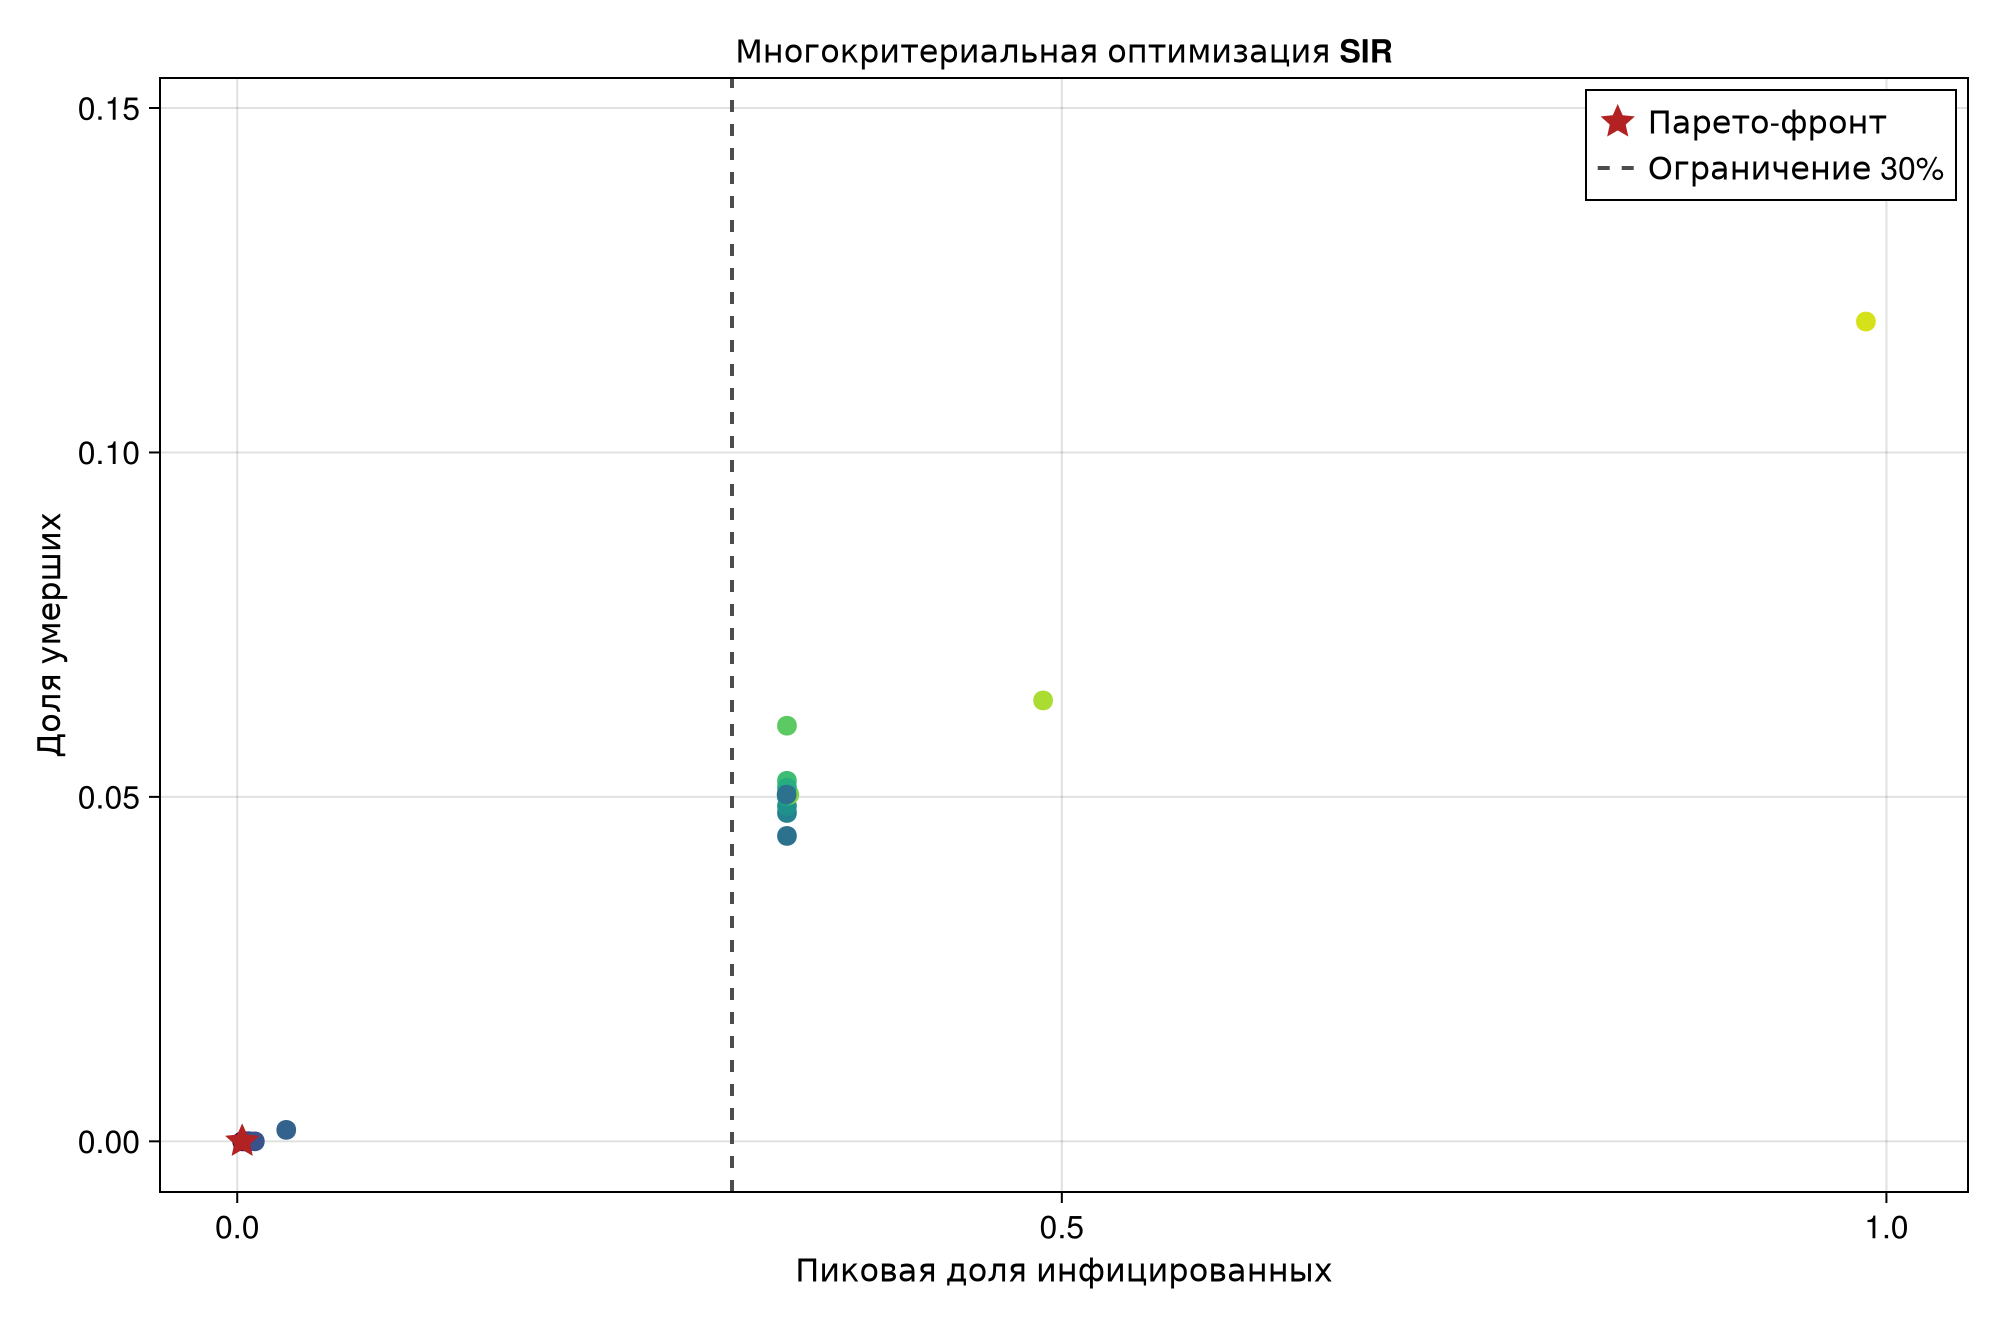

Row,generation,candidate,rank,crowding,detection_time,beta_detected,migration,quarantine_threshold,death_fraction,peak_fraction,raw_death_fraction,raw_peak_fraction
,Int64,Int64,Int64,Float64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,7,1,1,Inf,2,0.0160179,0.203237,0.101988,0.0,0.003,0.0,0.003


In [4]:
fig = Figure(size=(1000, 660))
ax = Axis(fig[1, 1], title="Многокритериальная оптимизация SIR",
          xlabel="Пиковая доля инфицированных", ylabel="Доля умерших")
scatter!(ax, final.raw_peak_fraction, final.raw_death_fraction;
         color=final.rank, colormap=:viridis, markersize=14)
scatter!(ax, pareto.raw_peak_fraction, pareto.raw_death_fraction;
         color=:firebrick, markersize=20, marker=:star5, label="Парето-фронт")
vlines!(ax, [0.30]; linestyle=:dash, color=:gray30, label="Ограничение 30%")
axislegend(ax; position=:rt)
save_figure(fig, "sir-optimize-parameters", "pareto-front.png";
            report_name="sir-pareto-optimization.png")
display(fig)
DataFrame([NamedTuple(best)])